In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/sales.csv",low_memory=False)
df.head()

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


In [2]:
df.shape

(286392, 33)

In [3]:
df.columns

Index(['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered',
       'price', 'discount_amount', 'category', 'payment_method', 'bi_st',
       'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name',
       'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail',
       'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City',
       'State', 'Zip', 'Region', 'User Name'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         286392 non-null  object 
 1   order_date       286392 non-null  object 
 2   status           286392 non-null  object 
 3   item_id          286392 non-null  int64  
 4   sku              286392 non-null  object 
 5   qty_ordered      286392 non-null  int64  
 6   price            286392 non-null  float64
 7   discount_amount  286392 non-null  float64
 8   category         286392 non-null  object 
 9   payment_method   286392 non-null  object 
 10  bi_st            286392 non-null  object 
 11  cust_id          286392 non-null  int64  
 12  year             286392 non-null  int64  
 13  month            286392 non-null  object 
 14  ref_num          286392 non-null  int64  
 15  Name Prefix      286392 non-null  object 
 16  First Name       286392 non-null  obje

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

order_id           0
Middle Initial     0
Region             0
Zip                0
State              0
City               0
County             0
Place Name         0
Phone No.          0
SSN                0
Customer Since     0
E Mail             0
full_name          0
age                0
Gender             0
Last Name          0
First Name         0
order_date         0
Name Prefix        0
ref_num            0
month              0
year               0
cust_id            0
bi_st              0
payment_method     0
category           0
discount_amount    0
price              0
qty_ordered        0
sku                0
item_id            0
status             0
User Name          0
dtype: int64

In [6]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

order_id           0.0
Middle Initial     0.0
Region             0.0
Zip                0.0
State              0.0
City               0.0
County             0.0
Place Name         0.0
Phone No.          0.0
SSN                0.0
Customer Since     0.0
E Mail             0.0
full_name          0.0
age                0.0
Gender             0.0
Last Name          0.0
First Name         0.0
order_date         0.0
Name Prefix        0.0
ref_num            0.0
month              0.0
year               0.0
cust_id            0.0
bi_st              0.0
payment_method     0.0
category           0.0
discount_amount    0.0
price              0.0
qty_ordered        0.0
sku                0.0
item_id            0.0
status             0.0
User Name          0.0
dtype: float64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
pd.to_datetime(
    df["order_date"],
    format="%d-%m-%Y",
    errors="coerce"
).isna().sum()

0

Convert order_date and Customer Since

In [9]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="%d-%m-%Y"
)


In [10]:
df["Customer Since"] = pd.to_datetime(
    df["Customer Since"],
    errors="coerce"
)

In [11]:
df["Customer Since"].head(20)

0    2006-08-22
1    2006-08-22
2    2006-08-22
3    2006-08-22
4    2006-08-22
5    2006-08-22
6    2006-08-22
7           NaT
8           NaT
9           NaT
10          NaT
11          NaT
12          NaT
13          NaT
14          NaT
15          NaT
16          NaT
17          NaT
18          NaT
19          NaT
Name: Customer Since, dtype: datetime64[ns]

In [12]:
pd.to_datetime(df["order_date"])

0        2020-10-01
1        2020-10-01
2        2020-10-01
3        2020-10-01
4        2020-11-13
            ...    
286387   2021-09-30
286388   2021-09-30
286389   2021-09-30
286390   2021-09-30
286391   2021-09-30
Name: order_date, Length: 286392, dtype: datetime64[ns]

Create Sales Column

In [13]:
df["Sales"] = df["qty_ordered"] * df["price"]

In [14]:
df[["qty_ordered", "price", "Sales"]].head()

,qty_ordered,price,Sales
0,21,89.9,1887.9
1,11,19.0,209.0
2,9,149.9,1349.1
3,9,79.9,719.1
4,2,99.9,199.8


check Revenue

In [15]:
print("Total Revenue :", df["Sales"].sum())

Total Revenue : 497538851.5579999


Check Invalid Transactions

In [16]:
print("Negative Quantity :", (df["qty_ordered"] < 0).sum())
print("Zero Quantity     :", (df["qty_ordered"] == 0).sum())

print("Negative Price    :", (df["price"] < 0).sum())
print("Zero Price        :", (df["price"] == 0).sum())

Negative Quantity : 0
Zero Quantity     : 0
Negative Price    : 0
Zero Price        : 1574


check order status

In [17]:
df["status"].value_counts()

status
canceled          112166
complete           88968
received           51775
order_refunded     25713
refund              3820
cod                 2851
paid                 756
closed               176
payment_review        57
pending               48
processing            33
holded                25
pending_paypal         4
Name: count, dtype: int64

filter successful orders

In [18]:
valid_status = ["complete", "received", "paid", "closed"]

df = df[df["status"].isin(valid_status)]

In [19]:
print(df.shape)

(141675, 34)


In [20]:
df["status"].value_counts()

status
complete    88968
received    51775
paid          756
closed        176
Name: count, dtype: int64

In [21]:
print("Total Revenue :", round(df["Sales"].sum(), 2))
print("Total Customers :", df["cust_id"].nunique())
print("Total Orders :", df["order_id"].nunique())
print("Average Order Value :", round(df["Sales"].mean(), 2))

Total Revenue : 182922985.09
Total Customers : 42174
Total Orders : 92875
Average Order Value : 1291.15


In [22]:
import matplotlib.pyplot as plt

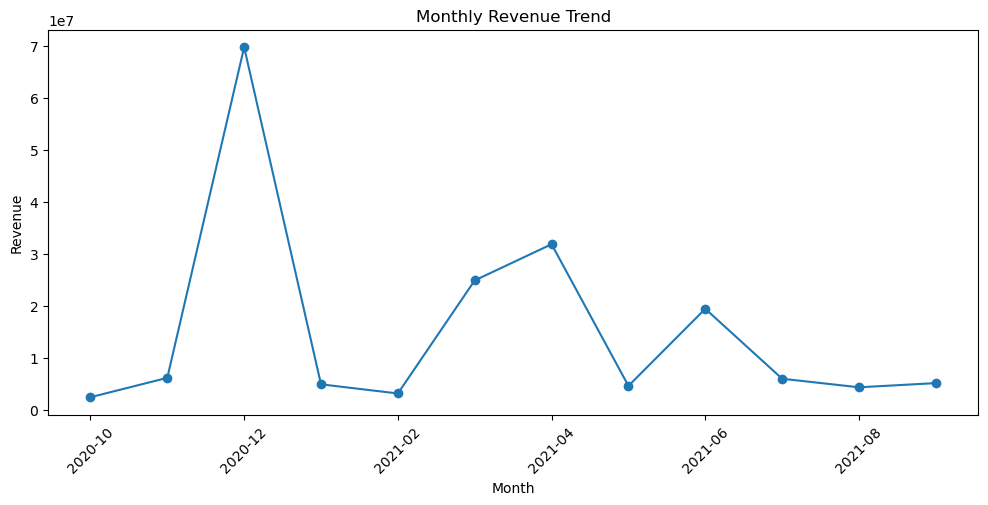

In [23]:
df["Month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

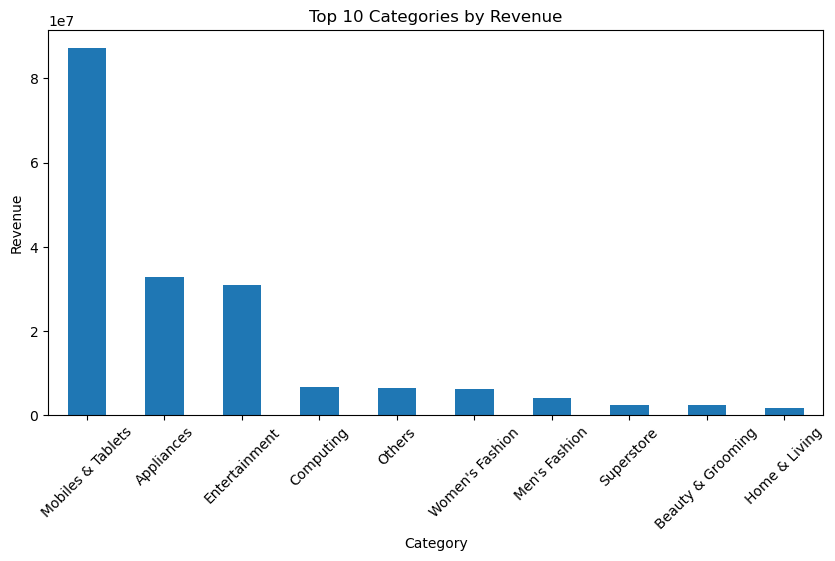

In [24]:
top_categories = (
    df.groupby("category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

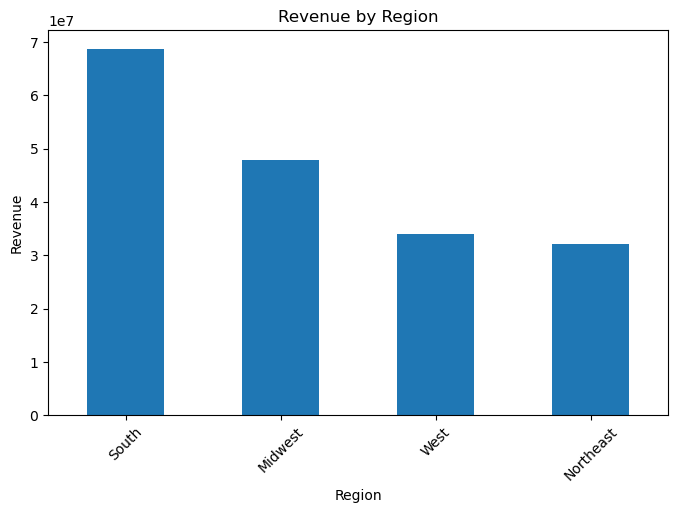

In [25]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [26]:
df.to_csv("../data/sales_clean.csv", index=False)